# IT4060 - HPC Failure Prediction

## Notebook: Horizon Comparison

This notebook extends [09_model_comparison.ipynb](09_model_comparison.ipynb) by comparing the strongest models across multiple prediction horizons. It uses the saved `6h` runs as reference and trains fresh `12h` and `24h` experiments for Extra Trees and Hist Gradient Boosting.

In [1]:
from pathlib import Path
import os
import time

os.environ.setdefault('OMP_NUM_THREADS', '1')
os.environ.setdefault('MKL_NUM_THREADS', '1')
os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score, f1_score, precision_recall_curve, precision_score, recall_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 220)
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (14, 6)


In [2]:
PROJECT_NAME = 'IT4060-ML-Assignment-HPC-Failure-Prediction'
TARGET_COLUMNS = ['label_next_12h', 'label_next_24h']
REFERENCE_TARGET = 'label_next_6h'
MODEL_DISPLAY_NAMES = {
    'extra_trees': 'Extra Trees',
    'hist_gradient_boosting': 'Hist Gradient Boosting',
}
DISPLAY_ORDER = ['extra_trees', 'hist_gradient_boosting']

def find_project_root():
    cwd = Path.cwd().resolve()
    home = Path.home().resolve()
    desktop = home / 'Desktop'
    candidate_roots = [cwd, *cwd.parents, home, desktop, desktop / 'Manilka' / 'ML_Assignment']
    seen = set()

    for base in candidate_roots:
        for candidate in (base, base / PROJECT_NAME):
            if candidate in seen or not candidate.exists():
                continue
            seen.add(candidate)
            if (candidate / 'data' / 'processed').exists() and (candidate / 'results').exists():
                return candidate

    raise FileNotFoundError('Could not locate the project root with data/processed and results/.')

project_root = find_project_root()
processed_path = project_root / 'data' / 'processed' / 'node_hour_features_multi_horizon.csv.gz'
results_dir = project_root / 'results'
comparison_results_dir = results_dir / 'horizon_comparison'
comparison_results_dir.mkdir(parents=True, exist_ok=True)

label_summary_path = comparison_results_dir / 'label_distribution_by_split_and_horizon.csv'
experiment_metadata_path = comparison_results_dir / 'experiment_metadata.csv'
validation_metrics_path = comparison_results_dir / 'validation_metrics_combined.csv'
test_metrics_path = comparison_results_dir / 'test_metrics_combined.csv'
ranking_path = comparison_results_dir / 'experiment_ranking.csv'
top_risk_path = comparison_results_dir / 'top_risk_preview.csv'
positive_rate_plot_path = comparison_results_dir / 'positive_rate_by_horizon.png'
metric_overview_plot_path = comparison_results_dir / 'horizon_metric_overview.png'
tradeoff_plot_path = comparison_results_dir / 'precision_recall_tradeoff_by_horizon.png'

print(f'Project root: {project_root}')
print(f'Processed data path: {processed_path}')
print(f'Results directory: {results_dir}')
print(f'Horizon comparison directory: {comparison_results_dir}')


Project root: D:\Projects\IT4060-ML-Assignment-HPC-Failure-Prediction
Processed data path: D:\Projects\IT4060-ML-Assignment-HPC-Failure-Prediction\data\processed\node_hour_features_multi_horizon.csv.gz
Results directory: D:\Projects\IT4060-ML-Assignment-HPC-Failure-Prediction\results
Horizon comparison directory: D:\Projects\IT4060-ML-Assignment-HPC-Failure-Prediction\results\horizon_comparison


In [3]:
df = pd.concat(
    pd.read_csv(
        processed_path,
        compression='gzip',
        low_memory=False,
        chunksize=100000,
    ),
    ignore_index=True,
)
df['hour'] = pd.to_datetime(df['hour'])
df['next_failure_time'] = pd.to_datetime(df['next_failure_time'])

target_columns = [column for column in df.columns if column.startswith('label_next_')]
feature_exclusions = ['hour', 'next_failure_time', 'hours_to_next_failure', *target_columns]
feature_columns = [column for column in df.columns if column not in feature_exclusions]

unique_hours = np.sort(df['hour'].unique())
train_end = int(len(unique_hours) * 0.70)
valid_end = int(len(unique_hours) * 0.85)

train_hours = unique_hours[:train_end]
valid_hours = unique_hours[train_end:valid_end]
test_hours = unique_hours[valid_end:]

train_df = df[df['hour'].isin(train_hours)].copy()
valid_df = df[df['hour'].isin(valid_hours)].copy()
test_df = df[df['hour'].isin(test_hours)].copy()

label_summary_rows = []
for target_column in [REFERENCE_TARGET, *TARGET_COLUMNS]:
    horizon_hours = int(target_column.split("_")[-1].replace("h", ""))
    for split_name, split_df in [("train", train_df), ("validation", valid_df), ("test", test_df)]:
        label_summary_rows.append({
            "target_column": target_column,
            "horizon_hours": horizon_hours,
            "split": split_name,
            "rows": len(split_df),
            "positives": int(split_df[target_column].sum()),
            "positive_rate": float(split_df[target_column].mean()),
        })

label_summary = pd.DataFrame(label_summary_rows)
label_summary.to_csv(label_summary_path, index=False)
display(label_summary)


,target_column,horizon_hours,split,rows,positives,positive_rate
0,label_next_6h,6,train,488782,577,0.001180
1,label_next_6h,6,validation,114395,76,0.000664
2,label_next_6h,6,test,84637,48,0.000567
3,label_next_12h,12,train,488782,1162,0.002377
4,label_next_12h,12,validation,114395,134,0.001171
5,label_next_12h,12,test,84637,78,0.000922
6,label_next_24h,24,train,488782,2358,0.004824
7,label_next_24h,24,validation,114395,305,0.002666
8,label_next_24h,24,test,84637,157,0.001855


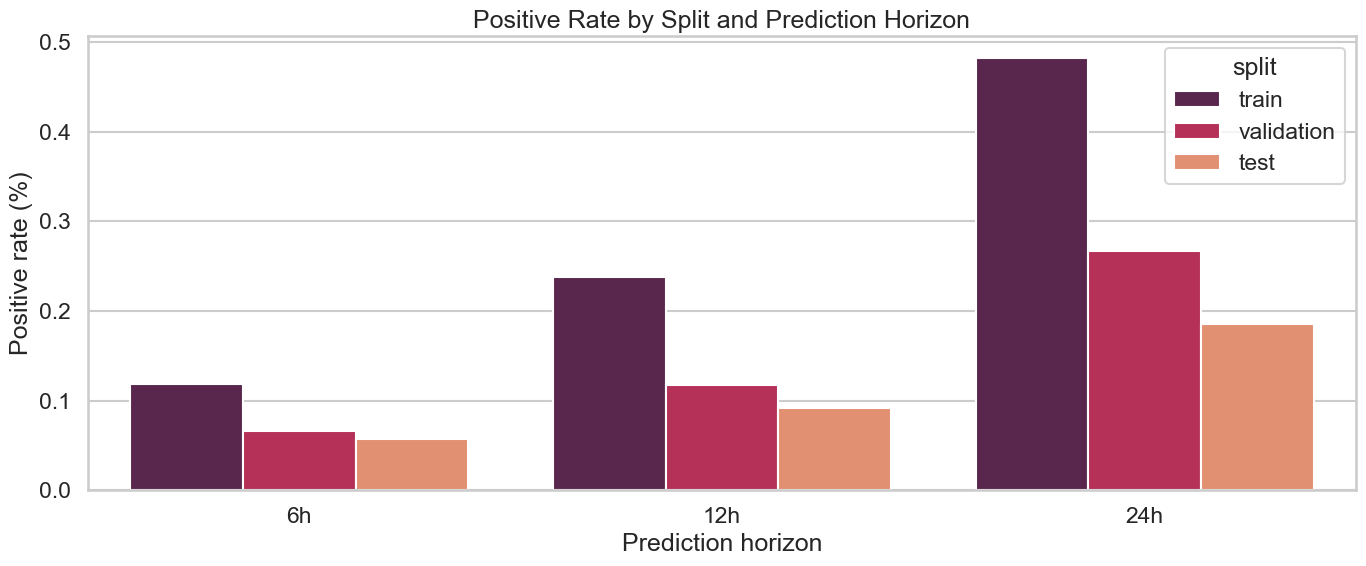

In [4]:
plot_df = label_summary.copy()
plot_df['positive_rate_percent'] = plot_df['positive_rate'] * 100
plot_df['horizon_label'] = plot_df['horizon_hours'].map(lambda value: f'{value}h')

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(data=plot_df, x='horizon_label', y='positive_rate_percent', hue='split', palette='rocket', ax=ax)
ax.set_title('Positive Rate by Split and Prediction Horizon')
ax.set_xlabel('Prediction horizon')
ax.set_ylabel('Positive rate (%)')
plt.tight_layout()
fig.savefig(positive_rate_plot_path, bbox_inches='tight')
plt.show()


In [5]:
def precision_at_k(y_true, scores, k=50):
    if len(scores) == 0:
        return np.nan
    k = min(k, len(scores))
    top_indices = np.argsort(scores)[::-1][:k]
    return float(np.asarray(y_true)[top_indices].mean())

def evaluate_scores(y_true, scores, threshold):
    predictions = (scores >= threshold).astype(int)
    return {
        'pr_auc': average_precision_score(y_true, scores),
        'roc_auc': roc_auc_score(y_true, scores),
        'precision': precision_score(y_true, predictions, zero_division=0),
        'recall': recall_score(y_true, predictions, zero_division=0),
        'f1': f1_score(y_true, predictions, zero_division=0),
        'predicted_positives': int(predictions.sum()),
        'precision_at_50': precision_at_k(y_true, scores, k=50),
    }

def build_threshold_outputs(y_true, scores, default_threshold=0.5):
    precision_curve, recall_curve, threshold_curve = precision_recall_curve(y_true, scores)
    f1_curve = 2 * precision_curve[:-1] * recall_curve[:-1] / np.clip(precision_curve[:-1] + recall_curve[:-1], 1e-12, None)
    best_threshold = float(threshold_curve[np.nanargmax(f1_curve)]) if len(threshold_curve) else default_threshold
    metrics_df = pd.DataFrame([
        {"threshold_strategy": "default", "threshold": default_threshold, **evaluate_scores(y_true, scores, default_threshold)},
        {"threshold_strategy": "best_validation", "threshold": best_threshold, **evaluate_scores(y_true, scores, best_threshold)},
    ])
    return metrics_df, best_threshold

def run_extra_trees(target_column):
    X_train = train_df[feature_columns]
    y_train = train_df[target_column]
    X_valid = valid_df[feature_columns]
    y_valid = valid_df[target_column]
    X_test = test_df[feature_columns]
    y_test = test_df[target_column]

    categorical_features = ['node']
    numeric_features = [column for column in feature_columns if column not in categorical_features]

    preprocessor = ColumnTransformer(
        transformers=[
            (
                'categorical',
                OneHotEncoder(handle_unknown='ignore', sparse_output=True),
                categorical_features,
            ),
            (
                'numeric',
                Pipeline(steps=[('imputer', SimpleImputer(strategy='constant', fill_value=0))]),
                numeric_features,
            ),
        ]
    )

    model_pipeline = Pipeline(
        steps=[
            ('preprocessor', preprocessor),
            ('model', ExtraTreesClassifier(
                n_estimators=200,
                max_depth=18,
                min_samples_leaf=5,
                max_features='sqrt',
                class_weight='balanced',
                n_jobs=1,
                random_state=42,
                verbose=0,
            )),
        ]
    )

    start = time.perf_counter()
    model_pipeline.fit(X_train, y_train)
    training_seconds = time.perf_counter() - start

    valid_scores = model_pipeline.predict_proba(X_valid)[:, 1]
    test_scores = model_pipeline.predict_proba(X_test)[:, 1]

    validation_metrics, best_threshold = build_threshold_outputs(y_valid, valid_scores, default_threshold=0.5)
    test_metrics, _ = build_threshold_outputs(y_test, test_scores, default_threshold=0.5)
    test_metrics.loc[test_metrics["threshold_strategy"] == "best_validation", "threshold"] = best_threshold

    top_risk = test_df[["node", "hour", target_column]].copy()
    top_risk["score"] = test_scores
    top_risk = top_risk.sort_values("score", ascending=False).head(10)

    metadata = {
        'model_name': 'extra_trees',
        'display_name': MODEL_DISPLAY_NAMES['extra_trees'],
        'target_column': target_column,
        "horizon_hours": int(target_column.split("_")[-1].replace("h", "")),
        "training_seconds": training_seconds,
        "train_positive_rate": float(y_train.mean()),
        "validation_positive_rate": float(y_valid.mean()),
        "test_positive_rate": float(y_test.mean()),
    }
    return metadata, validation_metrics, test_metrics, top_risk

def run_hist_gradient_boosting(target_column):
    X_train = train_df[feature_columns].copy()
    y_train = train_df[target_column]
    X_valid = valid_df[feature_columns].copy()
    y_valid = valid_df[target_column]
    X_test = test_df[feature_columns].copy()
    y_test = test_df[target_column]

    imputer = SimpleImputer(strategy='median')
    X_train.loc[:, feature_columns] = imputer.fit_transform(X_train[feature_columns])
    X_valid.loc[:, feature_columns] = imputer.transform(X_valid[feature_columns])
    X_test.loc[:, feature_columns] = imputer.transform(X_test[feature_columns])

    model = HistGradientBoostingClassifier(
        loss='log_loss',
        learning_rate=0.05,
        max_iter=200,
        max_leaf_nodes=31,
        max_depth=6,
        min_samples_leaf=50,
        l2_regularization=0.1,
        early_stopping=False,
        class_weight='balanced',
        random_state=42,
        verbose=0,
    )

    start = time.perf_counter()
    model.fit(X_train, y_train)
    training_seconds = time.perf_counter() - start

    valid_scores = model.predict_proba(X_valid)[:, 1]
    test_scores = model.predict_proba(X_test)[:, 1]

    validation_metrics, best_threshold = build_threshold_outputs(y_valid, valid_scores, default_threshold=0.5)
    test_metrics, _ = build_threshold_outputs(y_test, test_scores, default_threshold=0.5)
    test_metrics.loc[test_metrics["threshold_strategy"] == "best_validation", "threshold"] = best_threshold

    top_risk = test_df[["node", "hour", target_column]].copy()
    top_risk["score"] = test_scores
    top_risk = top_risk.sort_values("score", ascending=False).head(10)

    metadata = {
        'model_name': 'hist_gradient_boosting',
        'display_name': MODEL_DISPLAY_NAMES['hist_gradient_boosting'],
        'target_column': target_column,
        "horizon_hours": int(target_column.split("_")[-1].replace("h", "")),
        "training_seconds": training_seconds,
        "train_positive_rate": float(y_train.mean()),
        "validation_positive_rate": float(y_valid.mean()),
        "test_positive_rate": float(y_test.mean()),
    }
    return metadata, validation_metrics, test_metrics, top_risk

def load_reference_results(model_name):
    model_dir = results_dir / model_name
    metadata_df = pd.read_csv(model_dir / "run_metadata.csv")
    validation_df = pd.read_csv(model_dir / "validation_metrics.csv")
    test_df_metrics = pd.read_csv(model_dir / "test_metrics.csv")

    metadata = metadata_df.iloc[0].to_dict()
    metadata["model_name"] = model_name
    metadata["display_name"] = MODEL_DISPLAY_NAMES[model_name]
    metadata["horizon_hours"] = 6
    metadata["target_column"] = REFERENCE_TARGET
    metadata["training_seconds"] = np.nan

    validation_df = validation_df.copy()
    validation_df.insert(0, "model_name", model_name)
    validation_df.insert(1, "display_name", MODEL_DISPLAY_NAMES[model_name])
    validation_df.insert(2, "target_column", REFERENCE_TARGET)
    validation_df.insert(3, "horizon_hours", 6)
    validation_df.insert(4, "source", "reference_6h")
    validation_df.insert(5, "threshold_strategy", ["default", "best_validation"])

    test_df_metrics = test_df_metrics.copy()
    test_df_metrics.insert(0, "model_name", model_name)
    test_df_metrics.insert(1, "display_name", MODEL_DISPLAY_NAMES[model_name])
    test_df_metrics.insert(2, "target_column", REFERENCE_TARGET)
    test_df_metrics.insert(3, "horizon_hours", 6)
    test_df_metrics.insert(4, "source", "reference_6h")
    test_df_metrics.insert(5, "threshold_strategy", ["default", "best_validation"])
    return metadata, validation_df, test_df_metrics


In [6]:
metadata_rows = []
validation_frames = []
test_frames = []
top_risk_frames = []

for model_name in DISPLAY_ORDER:
    metadata, validation_df, test_df_metrics = load_reference_results(model_name)
    metadata_rows.append(metadata)
    validation_frames.append(validation_df)
    test_frames.append(test_df_metrics)

for target_column in TARGET_COLUMNS:
    print(f"Running horizon experiment for {target_column}...")
    for model_name in DISPLAY_ORDER:
        if model_name == "extra_trees":
            metadata, validation_df, test_df_metrics, top_risk = run_extra_trees(target_column)
        else:
            metadata, validation_df, test_df_metrics, top_risk = run_hist_gradient_boosting(target_column)

        validation_df = validation_df.copy()
        validation_df.insert(0, "model_name", metadata["model_name"])
        validation_df.insert(1, "display_name", metadata["display_name"])
        validation_df.insert(2, "target_column", metadata["target_column"])
        validation_df.insert(3, "horizon_hours", metadata["horizon_hours"])
        validation_df.insert(4, "source", "trained_in_10")

        test_df_metrics = test_df_metrics.copy()
        test_df_metrics.insert(0, "model_name", metadata["model_name"])
        test_df_metrics.insert(1, "display_name", metadata["display_name"])
        test_df_metrics.insert(2, "target_column", metadata["target_column"])
        test_df_metrics.insert(3, "horizon_hours", metadata["horizon_hours"])
        test_df_metrics.insert(4, "source", "trained_in_10")

        top_risk = top_risk.copy()
        top_risk.insert(0, "model_name", metadata["model_name"])
        top_risk.insert(1, "display_name", metadata["display_name"])
        top_risk.insert(2, "target_column", metadata["target_column"])
        top_risk.insert(3, "horizon_hours", metadata["horizon_hours"])

        metadata_rows.append(metadata)
        validation_frames.append(validation_df)
        test_frames.append(test_df_metrics)
        top_risk_frames.append(top_risk)

experiment_metadata = pd.DataFrame(metadata_rows)
validation_metrics = pd.concat(validation_frames, ignore_index=True)
test_metrics = pd.concat(test_frames, ignore_index=True)
top_risk_preview = pd.concat(top_risk_frames, ignore_index=True) if top_risk_frames else pd.DataFrame()

experiment_metadata.to_csv(experiment_metadata_path, index=False)
validation_metrics.to_csv(validation_metrics_path, index=False)
test_metrics.to_csv(test_metrics_path, index=False)
top_risk_preview.to_csv(top_risk_path, index=False)

display(experiment_metadata)
display(test_metrics[['display_name', 'target_column', 'threshold_strategy', 'threshold', 'pr_auc', 'roc_auc', 'precision', 'recall', 'f1', 'precision_at_50']])


Running horizon experiment for label_next_12h...
Running horizon experiment for label_next_24h...


,model_name,target_column,n_estimators,max_depth,min_samples_leaf,max_features,n_jobs,train_rows,validation_rows,test_rows,train_positive_rate,validation_positive_rate,test_positive_rate,display_name,horizon_hours,training_seconds,learning_rate,max_iter,max_leaf_nodes,l2_regularization,iterations_completed
0,extra_trees,label_next_6h,200.0,18.0,5.0,sqrt,1.0,488782.0,114395.0,84637.0,0.001180,0.000664,0.000567,Extra Trees,6,NaN,NaN,NaN,NaN,NaN,NaN
1,hist_gradient_boosting,label_next_6h,NaN,6.0,50.0,NaN,NaN,488782.0,114395.0,84637.0,0.001180,0.000664,0.000567,Hist Gradient Boosting,6,NaN,0.05,200.0,31.0,0.1,200.0
2,extra_trees,label_next_12h,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.002377,0.001171,0.000922,Extra Trees,12,89.162794,NaN,NaN,NaN,NaN,NaN
3,hist_gradient_boosting,label_next_12h,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.002377,0.001171,0.000922,Hist Gradient Boosting,12,16.989287,NaN,NaN,NaN,NaN,NaN
4,extra_trees,label_next_24h,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.004824,0.002666,0.001855,Extra Trees,24,81.571925,NaN,NaN,NaN,NaN,NaN
5,hist_gradient_boosting,label_next_24h,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.004824,0.002666,0.001855,Hist Gradient Boosting,24,16.622830,NaN,NaN,NaN,NaN,NaN


,display_name,target_column,threshold_strategy,threshold,pr_auc,roc_auc,precision,recall,f1,precision_at_50
0,Extra Trees,label_next_6h,default,0.500000,0.001372,0.594920,0.001077,0.250000,0.002145,0.00
1,Extra Trees,label_next_6h,best_validation,0.637549,0.001372,0.594920,0.003571,0.083333,0.006849,0.00
2,Hist Gradient Boosting,label_next_6h,default,0.500000,0.001257,0.552035,0.001187,0.125000,0.002352,0.02
3,Hist Gradient Boosting,label_next_6h,best_validation,0.832126,0.001257,0.552035,0.004505,0.020833,0.007407,0.02
4,Extra Trees,label_next_12h,default,0.500000,0.003811,0.630818,0.002093,0.397436,0.004163,0.00
5,Extra Trees,label_next_12h,best_validation,0.735897,0.003811,0.630818,0.020270,0.038462,0.026549,0.00
6,Hist Gradient Boosting,label_next_12h,default,0.500000,0.002519,0.596741,0.002248,0.217949,0.004450,0.00
7,Hist Gradient Boosting,label_next_12h,best_validation,0.824800,0.002519,0.596741,0.017668,0.064103,0.027701,0.00
8,Extra Trees,label_next_24h,default,0.500000,0.007528,0.619565,0.003146,0.426752,0.006247,0.00
9,Extra Trees,label_next_24h,best_validation,0.777912,0.007528,0.619565,0.026289,0.165605,0.045375,0.00


In [7]:
default_summary = test_metrics[test_metrics['threshold_strategy'] == 'default'].copy()
default_summary['horizon_label'] = default_summary['horizon_hours'].map(lambda value: f'{value}h')
default_summary['rank_pr_auc'] = default_summary['pr_auc'].rank(ascending=False, method='min')
default_summary['rank_precision_at_50'] = default_summary['precision_at_50'].rank(ascending=False, method='min')
default_summary['rank_roc_auc'] = default_summary['roc_auc'].rank(ascending=False, method='min')
default_summary['composite_rank_score'] = default_summary[['rank_pr_auc', 'rank_precision_at_50', 'rank_roc_auc']].mean(axis=1)
default_summary = default_summary.sort_values(['composite_rank_score', 'pr_auc', 'roc_auc'], ascending=[True, False, False])
default_summary.to_csv(ranking_path, index=False)
display(default_summary[['display_name', 'target_column', 'pr_auc', 'roc_auc', 'precision', 'recall', 'f1', 'precision_at_50', 'composite_rank_score']])


,display_name,target_column,pr_auc,roc_auc,precision,recall,f1,precision_at_50,composite_rank_score
8,Extra Trees,label_next_24h,0.007528,0.619565,0.003146,0.426752,0.006247,0.00,2.000000
4,Extra Trees,label_next_12h,0.003811,0.630818,0.002093,0.397436,0.004163,0.00,2.000000
10,Hist Gradient Boosting,label_next_24h,0.009062,0.593044,0.004716,0.292994,0.009284,0.00,2.666667
6,Hist Gradient Boosting,label_next_12h,0.002519,0.596741,0.002248,0.217949,0.004450,0.00,3.000000
0,Extra Trees,label_next_6h,0.001372,0.594920,0.001077,0.250000,0.002145,0.00,3.666667
2,Hist Gradient Boosting,label_next_6h,0.001257,0.552035,0.001187,0.125000,0.002352,0.02,4.333333


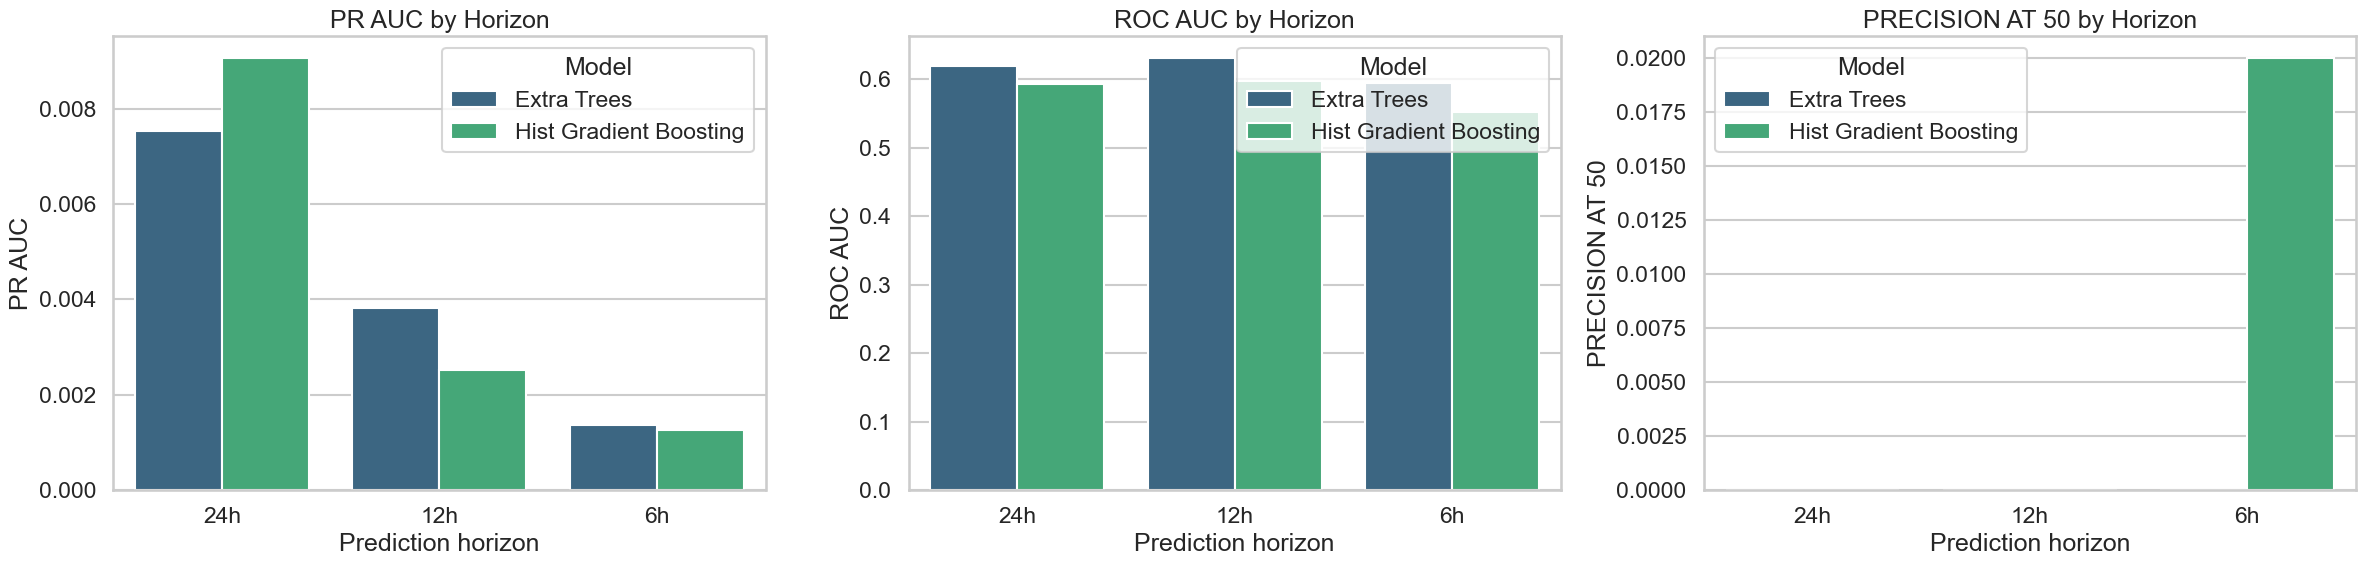

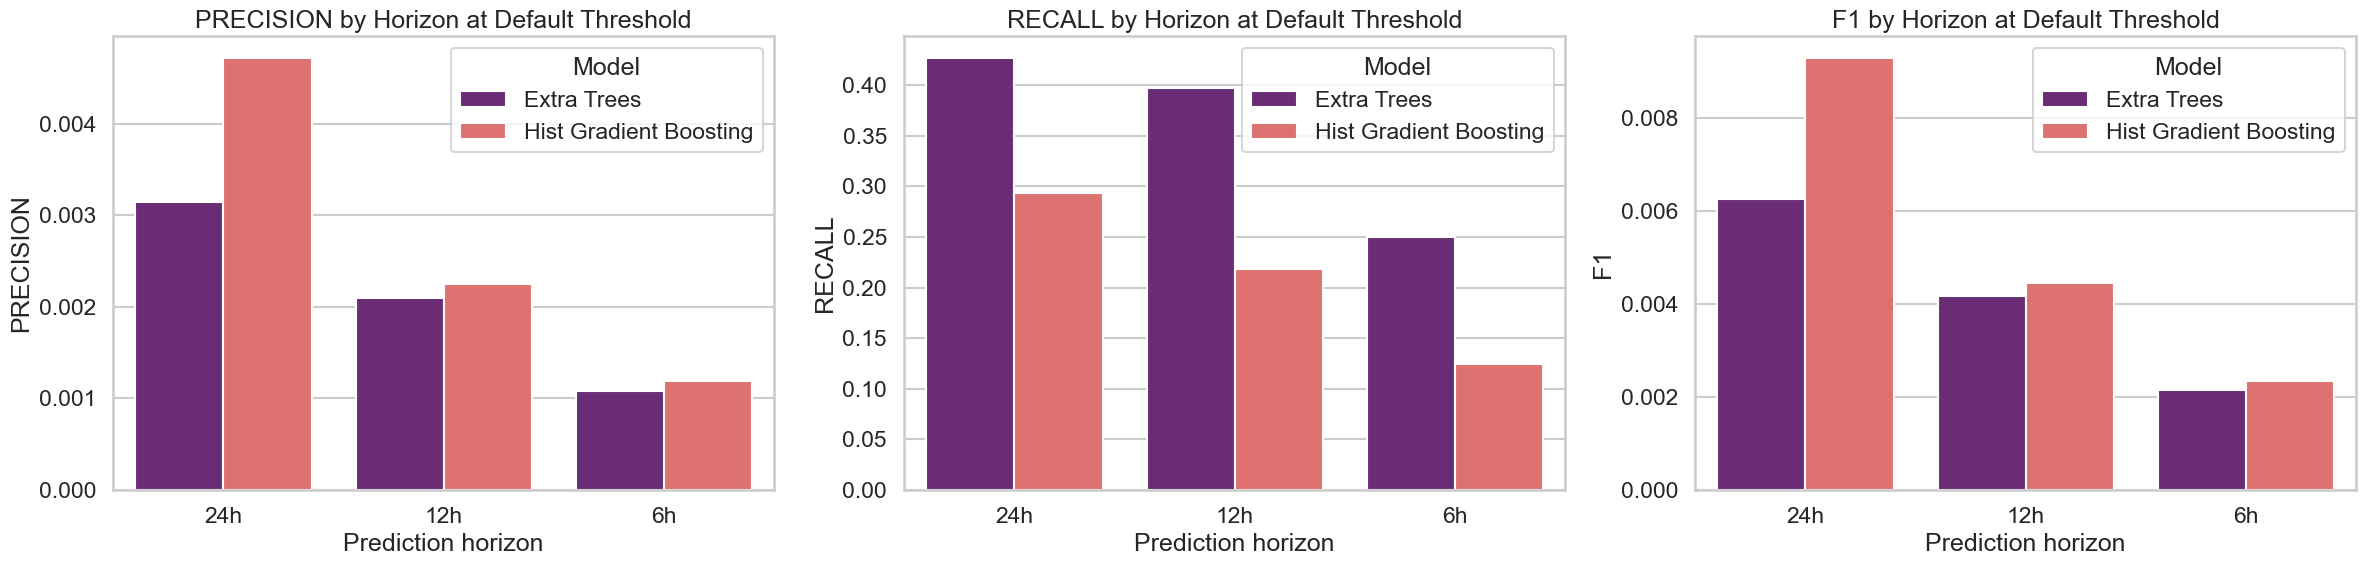

In [8]:
plot_df = default_summary.copy()

fig, axes = plt.subplots(1, 3, figsize=(24, 6))
for axis, metric in zip(axes, ['pr_auc', 'roc_auc', 'precision_at_50']):
    sns.barplot(data=plot_df, x='horizon_label', y=metric, hue='display_name', palette='viridis', ax=axis)
    axis.set_title(f"{metric.replace('_', ' ').upper()} by Horizon")
    axis.set_xlabel('Prediction horizon')
    axis.set_ylabel(metric.replace('_', ' ').upper())
    axis.legend(title='Model')

plt.tight_layout()
fig.savefig(metric_overview_plot_path, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(24, 6))
for axis, metric in zip(axes, ['precision', 'recall', 'f1']):
    sns.barplot(data=plot_df, x='horizon_label', y=metric, hue='display_name', palette='magma', ax=axis)
    axis.set_title(f'{metric.upper()} by Horizon at Default Threshold')
    axis.set_xlabel('Prediction horizon')
    axis.set_ylabel(metric.upper())
    axis.legend(title='Model')

plt.tight_layout()
fig.savefig(tradeoff_plot_path, bbox_inches='tight')
plt.show()


## Summary

This notebook extends [09_model_comparison.ipynb](09_model_comparison.ipynb) by testing whether the stronger tree-based models become more useful when the prediction horizon is widened. The key outputs are the horizon-level ranking table and the metric plots in `results/horizon_comparison/`, because they show whether `12h` or `24h` labels produce a more learnable target than `6h`.

Persisted comparison artifacts for this step are written to `results/horizon_comparison/`.
